In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Audio, display
from pynwb import NWBHDF5IO

import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, IntSlider, FloatSlider, Dropdown, Checkbox

from brain_audio_decoder import BrainAudioDecoder
from custom_decoder import CustomBrainAudioDecoder
from brain_audio_decoder_viz import BrainAudioDecoderViz
from acoustic_change_detector import AcousticChangeDetector
from phoneme_validator import PhonemeValidator
from phonetic_dictionary import PhoneticDictionary
from hybrid_phoneme_models import HybridPhonemeModels

In [2]:
# Define paths
path_bids = './SingleWordProductionDutch-iBIDS'
path_output = './features'
path_results = './results'

# Create directories if they don't exist
os.makedirs(path_output, exist_ok=True)
os.makedirs(path_results, exist_ok=True)

In [3]:
# Initialize the custom decoder
custom_decoder = CustomBrainAudioDecoder(
        path_bids=path_bids,
        path_output=path_output,
        path_results=path_results,
        debug_mode=False
    )

CustomBrainAudioDecoder: Initializing CustomBrainAudioDecoder with debug_mode=False


In [4]:
print("Stratifying participants...")
participant_strata = custom_decoder.stratify_participants_by_channel_quality(
        channel_correlation_threshold=0.1
    )

Stratifying participants...
CustomBrainAudioDecoder: 
Participant stratification results:
CustomBrainAudioDecoder:   Participants with most relevant channels: 3
CustomBrainAudioDecoder:   Participants with relevant channels: 4
CustomBrainAudioDecoder:   Participants with least relevant channels: 3
CustomBrainAudioDecoder: 
Top participants by channel quality:


In [5]:
# Create train/test split
split_result = custom_decoder.create_stratified_cross_word_split(
    participant_strata=participant_strata,
    test_ratio=0.2,
    min_word_freq=1,
    random_seed=42
)

CustomBrainAudioDecoder: Segmenting data for sub-06...
CustomBrainAudioDecoder: 
  Top 5 most frequent words:
CustomBrainAudioDecoder:     1. 'hoe': 1 instances
CustomBrainAudioDecoder:     2. 'zevenduizend': 1 instances
CustomBrainAudioDecoder:     3. 'en': 1 instances
CustomBrainAudioDecoder:     4. 'het': 1 instances
CustomBrainAudioDecoder:     5. 'smeekte': 1 instances
CustomBrainAudioDecoder: 
Example EEG segment shape: (3076, 127)
CustomBrainAudioDecoder: Example spectrogram segment shape: (300, 23)
CustomBrainAudioDecoder: Segmenting data for sub-07...
CustomBrainAudioDecoder: 
  Top 5 most frequent words:
CustomBrainAudioDecoder:     1. 'zanddak': 1 instances
CustomBrainAudioDecoder:     2. 'als': 1 instances
CustomBrainAudioDecoder:     3. 'terugvinden': 1 instances
CustomBrainAudioDecoder:     4. 'wegpakte': 1 instances
CustomBrainAudioDecoder:     5. 'onmiddellijk': 1 instances
CustomBrainAudioDecoder: 
Example EEG segment shape: (3076, 127)
CustomBrainAudioDecoder: Example

In [6]:
# Initialize detector
detector = AcousticChangeDetector(
    min_segment_duration=0.03,
    max_segment_duration=0.3,
    distance_metric='cosine',
    smoothing_window=3,
    peak_threshold=0.5,
    decoder=custom_decoder,
    debug_mode=True
)
detector.split_result = split_result

AcousticChangeDetector: Initialized with DEBUG_MODE=True


In [7]:
print("Accumulating training data...")
train = detector.accumulate_phoneme_data(
    num_batches=5,
    batch_size=32,
    feature_extraction_method='high_gamma',
    batch_type='train'
)

Accumulating training data...
AcousticChangeDetector: Accumulating train data from 5 batches...
AcousticChangeDetector: Processing batch 1/5
AcousticChangeDetector [DEBUG]: Processing batch with 32 instances
AcousticChangeDetector [DEBUG]: Original batch keys: ['eeg_segments', 'audio_segments', 'words', 'participant_ids', 'metadata', 'spectrogram_segments']
AcousticChangeDetector [DEBUG]: EEG segments in batch: True
AcousticChangeDetector [DEBUG]: Spectrogram segments in batch: True
AcousticChangeDetector [DEBUG]: Processing instance 0/32: 12
AcousticChangeDetector [DEBUG]: Added EEG segment with shape (3078, 127)
AcousticChangeDetector [DEBUG]: Detecting boundaries for word: 12
AcousticChangeDetector [DEBUG]: Estimated 4 phonemes for '12'
AcousticChangeDetector [DEBUG]: Added EEG segment with shape (3075, 127)
AcousticChangeDetector [DEBUG]: Detecting boundaries for word: mij
AcousticChangeDetector [DEBUG]: Estimated 2 phonemes for 'mij'
AcousticChangeDetector [DEBUG]: Added EEG segme

AcousticChangeDetector [DEBUG]: Processing segment 5 with shape (3076, 54)
AcousticChangeDetector [DEBUG]: Processing segment 6 with shape (3071, 117)
AcousticChangeDetector [DEBUG]: Processing segment 7 with shape (3077, 127)
AcousticChangeDetector [DEBUG]: Processing segment 8 with shape (3075, 127)
AcousticChangeDetector [DEBUG]: Processing segment 9 with shape (3076, 60)
AcousticChangeDetector [DEBUG]: Processing segment 10 with shape (3076, 127)
AcousticChangeDetector [DEBUG]: Processing segment 11 with shape (2647, 122)
AcousticChangeDetector [DEBUG]: Processing segment 12 with shape (3078, 127)
AcousticChangeDetector [DEBUG]: Processing segment 13 with shape (3077, 127)
AcousticChangeDetector [DEBUG]: Processing segment 14 with shape (3078, 122)
AcousticChangeDetector [DEBUG]: Processing segment 15 with shape (3076, 127)
AcousticChangeDetector [DEBUG]: Processing segment 16 with shape (3069, 54)
AcousticChangeDetector [DEBUG]: Processing segment 17 with shape (3072, 127)
Acousti

AcousticChangeDetector [DEBUG]: Processing segment 1 with shape (3075, 127)
AcousticChangeDetector [DEBUG]: Processing segment 2 with shape (3078, 122)
AcousticChangeDetector [DEBUG]: Processing segment 3 with shape (3075, 127)
AcousticChangeDetector [DEBUG]: Processing segment 4 with shape (3074, 115)
AcousticChangeDetector [DEBUG]: Processing segment 5 with shape (3076, 54)
AcousticChangeDetector [DEBUG]: Processing segment 6 with shape (3079, 117)
AcousticChangeDetector [DEBUG]: Processing segment 7 with shape (3075, 127)
AcousticChangeDetector [DEBUG]: Processing segment 8 with shape (3077, 127)
AcousticChangeDetector [DEBUG]: Processing segment 9 with shape (3076, 60)
AcousticChangeDetector [DEBUG]: Processing segment 10 with shape (3073, 127)
AcousticChangeDetector [DEBUG]: Processing segment 11 with shape (3075, 127)
AcousticChangeDetector [DEBUG]: Processing segment 12 with shape (3076, 127)
AcousticChangeDetector [DEBUG]: Processing segment 13 with shape (3077, 117)
AcousticCh

AcousticChangeDetector [DEBUG]: Processing segment 3 with shape (3076, 127)
AcousticChangeDetector [DEBUG]: Processing segment 4 with shape (3076, 115)
AcousticChangeDetector [DEBUG]: Processing segment 5 with shape (3081, 54)
AcousticChangeDetector [DEBUG]: Processing segment 6 with shape (3075, 117)
AcousticChangeDetector [DEBUG]: Processing segment 7 with shape (3077, 127)
AcousticChangeDetector [DEBUG]: Processing segment 8 with shape (3078, 127)
AcousticChangeDetector [DEBUG]: Processing segment 9 with shape (3073, 60)
AcousticChangeDetector [DEBUG]: Processing segment 10 with shape (3076, 127)
AcousticChangeDetector [DEBUG]: Processing segment 11 with shape (3077, 127)
AcousticChangeDetector [DEBUG]: Processing segment 12 with shape (3076, 127)
AcousticChangeDetector [DEBUG]: Processing segment 13 with shape (3077, 127)
AcousticChangeDetector [DEBUG]: Processing segment 14 with shape (3075, 60)
AcousticChangeDetector [DEBUG]: Processing segment 15 with shape (3076, 115)
AcousticC

AcousticChangeDetector [DEBUG]: Processing segment 2 with shape (3077, 122)
AcousticChangeDetector [DEBUG]: Processing segment 3 with shape (3074, 127)
AcousticChangeDetector [DEBUG]: Processing segment 4 with shape (3077, 115)
AcousticChangeDetector [DEBUG]: Processing segment 5 with shape (3075, 54)
AcousticChangeDetector [DEBUG]: Processing segment 6 with shape (3073, 117)
AcousticChangeDetector [DEBUG]: Processing segment 7 with shape (3072, 127)
AcousticChangeDetector [DEBUG]: Processing segment 8 with shape (3076, 127)
AcousticChangeDetector [DEBUG]: Processing segment 9 with shape (3074, 60)
AcousticChangeDetector [DEBUG]: Processing segment 10 with shape (3073, 127)
AcousticChangeDetector [DEBUG]: Processing segment 11 with shape (3073, 115)
AcousticChangeDetector [DEBUG]: Processing segment 12 with shape (3076, 127)
AcousticChangeDetector [DEBUG]: Processing segment 13 with shape (3074, 127)
AcousticChangeDetector [DEBUG]: Processing segment 14 with shape (3075, 54)
AcousticCh

AcousticChangeDetector [DEBUG]: Processing segment 1 with shape (3073, 127)
AcousticChangeDetector [DEBUG]: Processing segment 2 with shape (3069, 122)
AcousticChangeDetector [DEBUG]: Processing segment 3 with shape (3076, 127)
AcousticChangeDetector [DEBUG]: Processing segment 4 with shape (3077, 115)
AcousticChangeDetector [DEBUG]: Processing segment 5 with shape (3077, 54)
AcousticChangeDetector [DEBUG]: Processing segment 6 with shape (3080, 117)
AcousticChangeDetector [DEBUG]: Processing segment 7 with shape (3072, 127)
AcousticChangeDetector [DEBUG]: Processing segment 8 with shape (3075, 127)
AcousticChangeDetector [DEBUG]: Processing segment 9 with shape (3075, 60)
AcousticChangeDetector [DEBUG]: Processing segment 10 with shape (3074, 54)
AcousticChangeDetector [DEBUG]: Processing segment 11 with shape (2647, 122)
AcousticChangeDetector [DEBUG]: Processing segment 12 with shape (3071, 115)
AcousticChangeDetector [DEBUG]: Processing segment 13 with shape (3076, 127)
AcousticCha

In [8]:
test = detector.accumulate_phoneme_data(
    num_batches=3,
    batch_size=32,
    feature_extraction_method='high_gamma',
    batch_type='test'
)

AcousticChangeDetector: Accumulating test data from 3 batches...
AcousticChangeDetector: Processing batch 1/3
AcousticChangeDetector [DEBUG]: Processing batch with 32 instances
AcousticChangeDetector [DEBUG]: Original batch keys: ['eeg_segments', 'audio_segments', 'words', 'participant_ids', 'metadata', 'spectrogram_segments']
AcousticChangeDetector [DEBUG]: EEG segments in batch: True
AcousticChangeDetector [DEBUG]: Spectrogram segments in batch: True
AcousticChangeDetector [DEBUG]: Processing instance 0/32: 3
AcousticChangeDetector [DEBUG]: Added EEG segment with shape (3076, 127)
AcousticChangeDetector [DEBUG]: Detecting boundaries for word: 3
AcousticChangeDetector [DEBUG]: Estimated 3 phonemes for '3'
AcousticChangeDetector [DEBUG]: Added EEG segment with shape (3080, 127)
AcousticChangeDetector [DEBUG]: Detecting boundaries for word: hun
AcousticChangeDetector [DEBUG]: Estimated 3 phonemes for 'hun'
AcousticChangeDetector [DEBUG]: Added EEG segment with shape (3079, 122)
Acoustic

AcousticChangeDetector [DEBUG]: Processing segment 5 with shape (3079, 54)
AcousticChangeDetector [DEBUG]: Processing segment 6 with shape (3078, 117)
AcousticChangeDetector [DEBUG]: Processing segment 7 with shape (3071, 127)
AcousticChangeDetector [DEBUG]: Processing segment 8 with shape (3076, 127)
AcousticChangeDetector [DEBUG]: Processing segment 9 with shape (3073, 60)
AcousticChangeDetector [DEBUG]: Processing segment 10 with shape (3080, 117)
AcousticChangeDetector [DEBUG]: Processing segment 11 with shape (3076, 127)
AcousticChangeDetector [DEBUG]: Processing segment 12 with shape (3072, 115)
AcousticChangeDetector [DEBUG]: Processing segment 13 with shape (3077, 127)
AcousticChangeDetector [DEBUG]: Processing segment 14 with shape (3076, 127)
AcousticChangeDetector [DEBUG]: Processing segment 15 with shape (3075, 127)
AcousticChangeDetector [DEBUG]: Processing segment 16 with shape (3073, 127)
AcousticChangeDetector [DEBUG]: Processing segment 17 with shape (3075, 115)
Acoust

AcousticChangeDetector [DEBUG]: Processing segment 1 with shape (3080, 127)
AcousticChangeDetector [DEBUG]: Processing segment 2 with shape (3076, 122)
AcousticChangeDetector [DEBUG]: Processing segment 3 with shape (3074, 127)
AcousticChangeDetector [DEBUG]: Processing segment 4 with shape (3077, 115)
AcousticChangeDetector [DEBUG]: Processing segment 5 with shape (3078, 54)
AcousticChangeDetector [DEBUG]: Processing segment 6 with shape (3077, 117)
AcousticChangeDetector [DEBUG]: Processing segment 7 with shape (3079, 127)
AcousticChangeDetector [DEBUG]: Processing segment 8 with shape (3073, 127)
AcousticChangeDetector [DEBUG]: Processing segment 9 with shape (3076, 60)
AcousticChangeDetector [DEBUG]: Processing segment 10 with shape (3080, 117)
AcousticChangeDetector [DEBUG]: Processing segment 11 with shape (3076, 127)
AcousticChangeDetector [DEBUG]: Processing segment 12 with shape (3072, 115)
AcousticChangeDetector [DEBUG]: Processing segment 13 with shape (3077, 127)
AcousticCh

AcousticChangeDetector [DEBUG]: Processing segment 1 with shape (3074, 127)
AcousticChangeDetector [DEBUG]: Processing segment 2 with shape (3079, 122)
AcousticChangeDetector [DEBUG]: Processing segment 3 with shape (3076, 127)
AcousticChangeDetector [DEBUG]: Processing segment 4 with shape (3079, 115)
AcousticChangeDetector [DEBUG]: Processing segment 5 with shape (3075, 54)
AcousticChangeDetector [DEBUG]: Processing segment 6 with shape (3076, 117)
AcousticChangeDetector [DEBUG]: Processing segment 7 with shape (3076, 127)
AcousticChangeDetector [DEBUG]: Processing segment 8 with shape (3076, 127)
AcousticChangeDetector [DEBUG]: Processing segment 9 with shape (3075, 60)
AcousticChangeDetector [DEBUG]: Processing segment 10 with shape (3076, 54)
AcousticChangeDetector [DEBUG]: Processing segment 11 with shape (3076, 127)
AcousticChangeDetector [DEBUG]: Processing segment 12 with shape (3075, 127)
AcousticChangeDetector [DEBUG]: Processing segment 13 with shape (3077, 127)
AcousticCha

In [9]:
validator = PhonemeValidator(detector=detector)
validator.enable_debug()

PhonemeValidator: Initialized with DEBUG_MODE=False
PhonemeValidator: Debug mode enabled


In [10]:
# Resolve training data
if train['phoneme_labels'].count('?') > 0:
    train_converted = {
        'phoneme_labels': train['phoneme_labels'],
        'phoneme_spectrogram_segments': train.get('spectrograms', []),
        'phoneme_words': train['phoneme_words'],
        'phoneme_positions': train.get('phoneme_positions', [0] * len(train['phoneme_labels'])),
        'phoneme_participant_ids': train.get('phoneme_participant_ids', ['unknown'] * len(train['phoneme_labels']))
    }
    
    resolved_train = validator.resolve_unknown_phonemes(train_converted)
    train['phoneme_labels'] = resolved_train['phoneme_labels']
    print(f"\nTraining after resolution: {train['phoneme_labels'].count('?')} unknown phonemes")

PhonemeValidator [DEBUG]: Attempting to resolve 32 unknown phonemes
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'maantje' as 'm'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'maantje' as 'm'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'maantje' as 'm'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'maantje' as 'm'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'maantje' as 'm'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'of' as 'ɔf'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'of' as 'ɔf'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'of' as 'ɔf'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'of' as 'ɔf'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'of' as 'ɔf'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'of' as 'ɔf'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'of' as 'ɔf'
PhonemeValidator [DEBUG]: Resolved p

In [11]:
# Resolve test data
if test['phoneme_labels'].count('?') > 0:
    test_converted = {
        'phoneme_labels': test['phoneme_labels'],
        'phoneme_spectrogram_segments': test.get('spectrograms', []),
        'phoneme_words': test['phoneme_words'],
        'phoneme_positions': test.get('phoneme_positions', [0] * len(test['phoneme_labels'])),
        'phoneme_participant_ids': test.get('phoneme_participant_ids', ['unknown'] * len(test['phoneme_labels']))
    }
    
    resolved_test = validator.resolve_unknown_phonemes(test_converted)
    test['phoneme_labels'] = resolved_test['phoneme_labels']
    print(f"Test after resolution: {test['phoneme_labels'].count('?')} unknown phonemes")

PhonemeValidator [DEBUG]: Attempting to resolve 26 unknown phonemes
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'dichtbij' as 'd'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'dichtbij' as 'd'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'dichtbij' as 'd'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'dichtbij' as 'd'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'dichtbij' as 'd'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'aan' as 'a'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'aan' as 'a'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'aan' as 'a'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'direct' as 'd'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'direct' as 'd'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'direct' as 'd'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'direct' as 'd'
PhonemeValidator [D

In [12]:
total_words = sum(len(participant_data) for participant_data in detector.split_result['train'].values())
total_test_words = sum(len(participant_data) for participant_data in detector.split_result['test'].values())
print(f"Total training words: {total_words}, Total test words: {total_test_words}")

Total training words: 790, Total test words: 205


In [13]:
# 3. Add phoneme groups to PhoneticDictionary
phonetic_dict = detector.phonetic_dict
if not hasattr(phonetic_dict, 'phoneme_groups'):
    phonetic_dict.add_phoneme_groups()
    
# 4. Map phonemes to phoneme groups
print("Mapping phonemes to phoneme groups")
train_group_labels = [phonetic_dict.get_phoneme_group(p) or 'unknown' for p in train['phoneme_labels']]
test_group_labels = [phonetic_dict.get_phoneme_group(p) or 'unknown' for p in test['phoneme_labels']] 

Mapping phonemes to phoneme groups


In [14]:
hybrid_models = HybridPhonemeModels(
    phonetic_dict=detector.phonetic_dict,
    debug_mode=True
)

In [15]:
filtered_features = []
filtered_labels = []

for i, label in enumerate(train['phoneme_labels']):
    group = detector.phonetic_dict.phoneme_to_group.get(label, 'unknown')
    
    # Keep all non-unknown, but only keep 10% of unknown
    if group != 'unknown' or np.random.random() < 0.1:
        filtered_features.append(train['features'][i])
        filtered_labels.append(train['phoneme_labels'][i])

print(f"Filtered: {len(filtered_features)} from {len(train['features'])} samples")

Filtered: 134 from 160 samples


In [16]:
# 3. Train hybrid models with filtered data
# GMM Model
gmm_accuracy = hybrid_models.train_gmm_model(
    features=filtered_features,  # Same filtered features
    labels=filtered_labels,      # Same filtered labels
    n_components=3               # Reduce components for limited data
)

# XGBoost Model  
xgb_accuracy = hybrid_models.train_xgboost_model(
    features=filtered_features,
    labels=filtered_labels
)

# Ensemble Model
ensemble_accuracy = hybrid_models.train_ensemble_model(
    features=filtered_features,
    labels=filtered_labels,
    use_voting=True
)

HybridPhonemeModels: Training GMM model...
HybridPhonemeModels: Reduced features from 350 to 50 dimensions


C:\Users\irina\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\irina\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\irina\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\irina\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Window

HybridPhonemeModels: Reduced features from 350 to 50 dimensions
HybridPhonemeModels: GMM training complete. Accuracy: 0.3806
HybridPhonemeModels: Training XGBoost model...
HybridPhonemeModels: Reduced features from 350 to 50 dimensions
HybridPhonemeModels: Training with 134 samples, 8 classes
HybridPhonemeModels: Adjusted params: max_depth=3, n_estimators=67
HybridPhonemeModels: XGBoost training complete. Accuracy: 0.7910
HybridPhonemeModels: Top 5 important features: [34 42 12  3 25]
HybridPhonemeModels: Training ensemble model...
HybridPhonemeModels: Reduced features from 350 to 50 dimensions
HybridPhonemeModels: Trained rf successfully
HybridPhonemeModels: Trained et successfully
HybridPhonemeModels: Trained svm successfully
HybridPhonemeModels: Trained knn successfully
HybridPhonemeModels: Trained lda successfully
HybridPhonemeModels: Reduced features from 350 to 50 dimensions
HybridPhonemeModels: Ensemble training complete. Accuracy: 0.6791


In [17]:
# 4. Test with UNFILTERED test data (important!)
test_predictions_gmm = hybrid_models.predict_gmm(test['features'])
test_predictions_xgb = hybrid_models.predict_xgboost(test['features'])
test_predictions_ensemble = hybrid_models.predict_ensemble(test['features'])

HybridPhonemeModels: Reduced features from 350 to 50 dimensions
HybridPhonemeModels: Reduced features from 350 to 50 dimensions
HybridPhonemeModels: Reduced features from 350 to 50 dimensions


In [18]:
# This trains and tests all models at once
comparison_results = hybrid_models.compare_all_models(
    train_features=filtered_features,  # Filtered training features
    train_labels=filtered_labels,      # Filtered training labels
    test_features=test['features'],    # Original test features (unfiltered!)
    test_labels=test['phoneme_labels'] # Original test labels
)

print("\nModel Comparison Results:")
for model_name, scores in comparison_results.items():
    print(f"{model_name:15} | Train: {scores['train_acc']:.4f} | Test: {scores['test_acc']:.4f}")

HybridPhonemeModels: Comparing all models...
HybridPhonemeModels: 
Training GMM...
HybridPhonemeModels: Training GMM model...
HybridPhonemeModels: Reduced features from 350 to 50 dimensions


C:\Users\irina\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\irina\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\irina\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\irina\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Window

HybridPhonemeModels: Reduced features from 350 to 50 dimensions
HybridPhonemeModels: GMM training complete. Accuracy: 0.3433
HybridPhonemeModels: Reduced features from 350 to 50 dimensions
HybridPhonemeModels: GMM - Train: 0.3433, Test: 0.2708
HybridPhonemeModels: 
Training Ensemble...
HybridPhonemeModels: Training ensemble model...
HybridPhonemeModels: Reduced features from 350 to 50 dimensions
HybridPhonemeModels: Trained rf successfully
HybridPhonemeModels: Trained et successfully
HybridPhonemeModels: Trained svm successfully
HybridPhonemeModels: Trained knn successfully
HybridPhonemeModels: Trained lda successfully
HybridPhonemeModels: Reduced features from 350 to 50 dimensions
HybridPhonemeModels: Ensemble training complete. Accuracy: 0.6791
HybridPhonemeModels: Reduced features from 350 to 50 dimensions
HybridPhonemeModels: Ensemble - Train: 0.6791, Test: 0.3125
HybridPhonemeModels: 
Training XGBoost...
HybridPhonemeModels: Training XGBoost model...
HybridPhonemeModels: Reduced f

C:\Users\irina\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\irina\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\irina\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\irina\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environme

HybridPhonemeModels: Reduced features from 350 to 50 dimensions
HybridPhonemeModels: Prototype model training complete. Accuracy: 0.4328
HybridPhonemeModels: Reduced features from 350 to 50 dimensions
HybridPhonemeModels: Prototype - Train: 0.4328, Test: 0.0417

Model Comparison Results:
GMM             | Train: 0.3433 | Test: 0.2708
Ensemble        | Train: 0.6791 | Test: 0.3125
XGBoost         | Train: 0.7910 | Test: 0.2917
Prototype       | Train: 0.4328 | Test: 0.0417


In [19]:
# Print comparison
print("\nModel Comparison Results:")
print("-" * 40)
for model_name, scores in comparison_results.items():
    print(f"{model_name:15} | Train: {scores['train_acc']:.4f} | Test: {scores['test_acc']:.4f}")



Model Comparison Results:
----------------------------------------
GMM             | Train: 0.3433 | Test: 0.2708
Ensemble        | Train: 0.6791 | Test: 0.3125
XGBoost         | Train: 0.7910 | Test: 0.2917
Prototype       | Train: 0.4328 | Test: 0.0417


In [20]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix", figsize=(6, 4)):
    """
    Simple confusion matrix plotter for hybrid models.

    """
    # Get unique labels
    labels = sorted(list(set(y_true + y_pred)))
    
    # Create confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    
    # Plot
    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
    
    return cm

HybridPhonemeModels: Reduced features from 350 to 50 dimensions


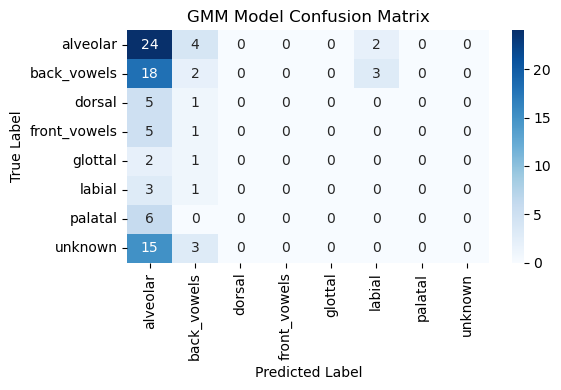

array([[24,  4,  0,  0,  0,  2,  0,  0],
       [18,  2,  0,  0,  0,  3,  0,  0],
       [ 5,  1,  0,  0,  0,  0,  0,  0],
       [ 5,  1,  0,  0,  0,  0,  0,  0],
       [ 2,  1,  0,  0,  0,  0,  0,  0],
       [ 3,  1,  0,  0,  0,  0,  0,  0],
       [ 6,  0,  0,  0,  0,  0,  0,  0],
       [15,  3,  0,  0,  0,  0,  0,  0]], dtype=int64)

In [21]:
# 1. For GMM model
gmm_predictions = hybrid_models.predict_gmm(test['features'])
gmm_true = [phonetic_dict.phoneme_to_group.get(l, 'unknown') for l in test['phoneme_labels']]
plot_confusion_matrix(gmm_true, gmm_predictions, title="GMM Model Confusion Matrix")

HybridPhonemeModels: Reduced features from 350 to 50 dimensions


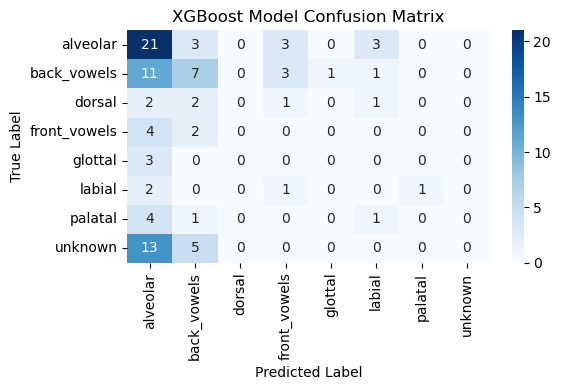

array([[21,  3,  0,  3,  0,  3,  0,  0],
       [11,  7,  0,  3,  1,  1,  0,  0],
       [ 2,  2,  0,  1,  0,  1,  0,  0],
       [ 4,  2,  0,  0,  0,  0,  0,  0],
       [ 3,  0,  0,  0,  0,  0,  0,  0],
       [ 2,  0,  0,  1,  0,  0,  1,  0],
       [ 4,  1,  0,  0,  0,  1,  0,  0],
       [13,  5,  0,  0,  0,  0,  0,  0]], dtype=int64)

In [22]:
# 2. For XGBoost model
xgb_predictions = hybrid_models.predict_xgboost(test['features'])
plot_confusion_matrix(gmm_true, xgb_predictions, title="XGBoost Model Confusion Matrix")

HybridPhonemeModels: Reduced features from 350 to 50 dimensions


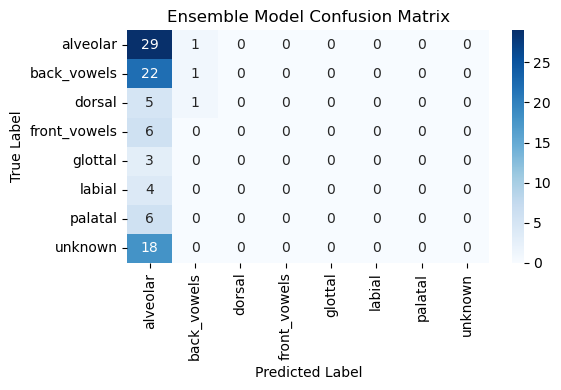

array([[29,  1,  0,  0,  0,  0,  0,  0],
       [22,  1,  0,  0,  0,  0,  0,  0],
       [ 5,  1,  0,  0,  0,  0,  0,  0],
       [ 6,  0,  0,  0,  0,  0,  0,  0],
       [ 3,  0,  0,  0,  0,  0,  0,  0],
       [ 4,  0,  0,  0,  0,  0,  0,  0],
       [ 6,  0,  0,  0,  0,  0,  0,  0],
       [18,  0,  0,  0,  0,  0,  0,  0]], dtype=int64)

In [23]:
# 3. For Ensemble model
ensemble_predictions = hybrid_models.predict_ensemble(test['features'])
plot_confusion_matrix(gmm_true, ensemble_predictions, title="Ensemble Model Confusion Matrix")